## Costo de Capital — CAPM 

Para estimar el costo de capital de Tesla usando el modelo CAPM se utilizan los resultados de los módulos anteriores:

$$E(R_i) = R_f + \beta_i \times (R_m - R_f)$$

| Variable | Valor | Fuente |
|----------|-------|--------|
| Rf | 4.48% | GS10 actual (FRED) |
| Prima de riesgo (Rm − Rf) | 8.86% | S&P 500 2020–2025 |
| Beta (β) | 1.83 | Regresión mensual 60 meses |

**Resultado:** el costo de capital accionario (Ke) de Tesla es **20.69%** , es decir, los accionistas 
exigen ese retorno mínimo como compensación por el riesgo de invertir en la empresa.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
# Parámetros calculados en módulos anteriores
RF = 4.48        # Tasa libre de riesgo (GS10 actual)
PRIMA = 8.86     # Prima de riesgo del mercado (Rm - Rf)
BETA_TSLA = 1.83 # Beta de Tesla (regresión mensual 60 meses)

In [2]:
costo_capital = RF + BETA_TSLA * PRIMA

print(f"Tasa libre de riesgo (Rf):        {RF:.2f}%")
print(f"Beta de Tesla (β):                {BETA_TSLA:.2f}")
print(f"Prima de riesgo (Rm - Rf):        {PRIMA:.2f}%")
print(f"─────────────────────────────────────────")
print(f"Costo de capital de Tesla (CAPM): {costo_capital:.2f}%")

Tasa libre de riesgo (Rf):        4.48%
Beta de Tesla (β):                1.83
Prima de riesgo (Rm - Rf):        8.86%
─────────────────────────────────────────
Costo de capital de Tesla (CAPM): 20.69%


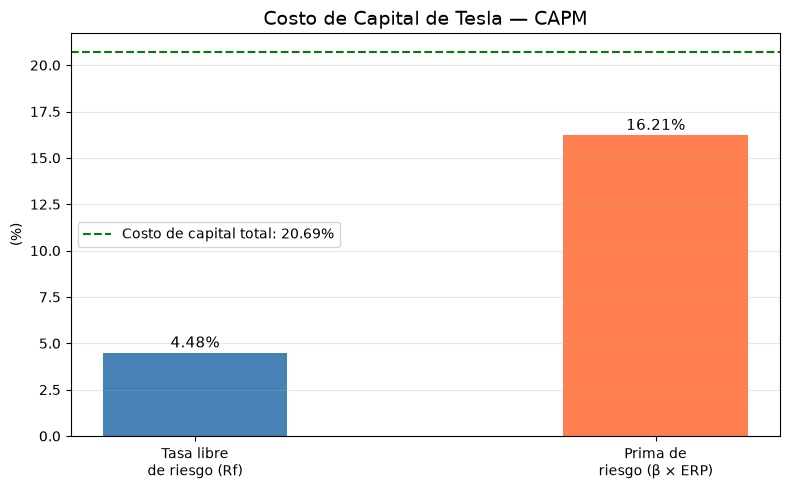

In [3]:
componentes = {
    'Tasa libre\nde riesgo (Rf)': RF,
    'Prima de\nriesgo (β × ERP)': BETA_TSLA * PRIMA,
}

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(componentes.keys(), componentes.values(), 
              color=['steelblue', 'coral'], width=0.4)

ax.axhline(costo_capital, color='green', linestyle='--', linewidth=1.5,
           label=f'Costo de capital total: {costo_capital:.2f}%')

for bar, val in zip(bars, componentes.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', fontsize=11)

ax.set_title('Costo de Capital de Tesla — CAPM', fontsize=14)
ax.set_ylabel('(%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Del Ke al WACC

El CAPM nos da el **costo del capital accionario (Ke)** , es decir, lo que exigen los accionistas.
Pero las empresas también se financian con deuda. El **WACC** promedia ambos costos 
según la estructura de capital de la empresa:

$$WACC = K_e \times \frac{E}{V} + K_d \times (1-t) \times \frac{D}{V}$$

El costo de la deuda (Kd) se multiplica por (1−t) porque los intereses son deducibles 
de impuestos 

**Hallazgo para Tesla:** el WACC (20.50%) es prácticamente igual al Ke (20.69%) porque 
Tesla se financia un 99% con capital accionario. La deuda representa apenas el 1% de su 
estructura de capital.

In [4]:
tsla = yf.Ticker("TSLA")

In [5]:
print("Deuda total:     ", tsla.info.get('totalDebt'))
print("Market Cap:      ", tsla.info.get('marketCap'))
print("Deuda/Capital:   ", tsla.info.get('debtToEquity'))
print()

# Estados financieros
print(tsla.financials.loc[['Tax Provision', 'Pretax Income', 'Interest Expense']].iloc[:, 0])

Deuda total:      15889999872
Market Cap:       1545179889664
Deuda/Capital:    18.738

Tax Provision       1.423000e+09
Pretax Income       5.278000e+09
Interest Expense    3.380000e+08
Name: 2025-12-31 00:00:00, dtype: float64


In [6]:
# Datos de Tesla
deuda = 15889999872
market_cap = 1538419589120
interest_expense = 338000000
tax_provision = 1423000000
pretax_income = 5278000000

# Cálculos
kd = (interest_expense / deuda) * 100
t = tax_provision / pretax_income
V = deuda + market_cap
E_V = market_cap / V
D_V = deuda / V

print(f"Costo de la deuda (Kd):          {kd:.2f}%")
print(f"Tasa impositiva efectiva (t):     {t*100:.2f}%")
print(f"Proporción capital (E/V):         {E_V*100:.2f}%")
print(f"Proporción deuda (D/V):           {D_V*100:.2f}%")

Costo de la deuda (Kd):          2.13%
Tasa impositiva efectiva (t):     26.96%
Proporción capital (E/V):         98.98%
Proporción deuda (D/V):           1.02%


In [7]:
WACC = (E_V * costo_capital) + (D_V * kd * (1 - t))

print(f"Ke (costo del capital):           {costo_capital:.2f}%")
print(f"Kd después de impuestos:          {kd * (1-t):.2f}%")
print(f"─────────────────────────────────────────")
print(f"WACC de Tesla:                    {WACC:.2f}%")

Ke (costo del capital):           20.69%
Kd después de impuestos:          1.55%
─────────────────────────────────────────
WACC de Tesla:                    20.50%


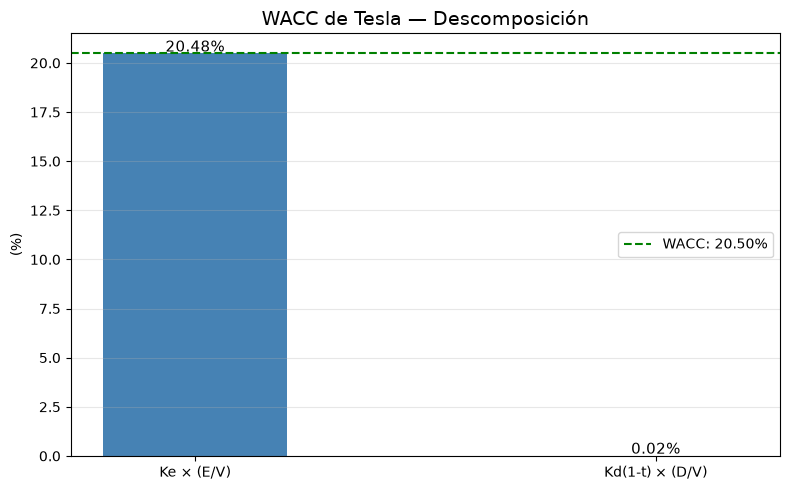

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

componentes = ['Ke × (E/V)', 'Kd(1-t) × (D/V)']
valores = [E_V * costo_capital, D_V * kd * (1 - t)]

bars = ax.bar(componentes, valores, color=['steelblue', 'coral'], width=0.4)

ax.axhline(WACC, color='green', linestyle='--', linewidth=1.5,
           label=f'WACC: {WACC:.2f}%')

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', fontsize=11)

ax.set_title('WACC de Tesla — Descomposición', fontsize=14)
ax.set_ylabel('(%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()